In [147]:
# Import required packages
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

In [148]:
# Directories
PROJECT_DIR = r"C:/Users/skazempour/Dropbox/Projects/42 - Machine learning from the crowd/"

CODE_DIR = os.path.join(PROJECT_DIR, "Code")
DATA_DIR = os.path.join(PROJECT_DIR, "Data")
FIGURES_DIR = os.path.join(PROJECT_DIR, "Figures")
TABLES_DIR = os.path.join(PROJECT_DIR, "Tables")

# File names
INPUT_DATA = os.path.join(DATA_DIR, "merged_master.pkl")

# Sample period
SAMPLE_START = '2012-01-01'
SAMPLE_END = '2022-12-31'

# Model registry: add new models here
# Key = column name in the dataframe, Value = prediction filename
MODELS = {
    'lr_2': 'predictions_linear_regression_input=2.pkl',
    'lr_56': 'predictions_linear_regression_input=56.pkl',
}

In [149]:
# Load base data (actual returns + raw_volume to identify no-tweet observations)
TARGET = 'f_cumret1'
df = pd.read_pickle(INPUT_DATA)[['date', 'permno', 'ticker', TARGET, 'log_volume']].copy()

# Merge predictions from each model
for model_name, pred_file in MODELS.items():
    preds = pd.read_pickle(os.path.join(DATA_DIR, pred_file))
    df[model_name] = preds.set_index('index')['prediction']

# Keep only rows with at least one prediction (OOS period)
model_cols = list(MODELS.keys())
df = df.dropna(subset=model_cols, how='all').reset_index(drop=True)

# Add time period columns and restrict to sample period
df['date'] = pd.to_datetime(df['date'])
df = df[(df['date'] >= SAMPLE_START) & (df['date'] <= SAMPLE_END)].reset_index(drop=True)
df['year_month'] = df['date'].dt.to_period('M')
df['year'] = df['date'].dt.year

print(f"OOS sample: {len(df):,} rows")
print(f"Period: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Models loaded: {model_cols}")
for col in model_cols:
    print(f"  {col}: {df[col].notna().sum():,} predictions")

OOS sample: 12,047,638 rows
Period: 2012-01-03 to 2022-12-30
Models loaded: ['lr_2', 'lr_56']
  lr_2: 12,047,638 predictions
  lr_56: 12,047,638 predictions


In [150]:
# Drop stock-days with no tweets (log_volume == 0 means no StockTwits messages)
n_before = len(df)
df = df[df['log_volume'] > 0].reset_index(drop=True)
print(f"Dropped {n_before - len(df):,} no-tweet observations ({(n_before - len(df)) / n_before:.1%})")
print(f"Remaining: {len(df):,} rows")

Dropped 8,876,307 no-tweet observations (73.7%)
Remaining: 3,171,331 rows


In [151]:
# Cross-sectionally de-mean the target and predictions each day
daily_means = df.groupby('date')[[TARGET] + model_cols].transform('mean')
df[TARGET] = df[TARGET] - daily_means[TARGET]
for col in model_cols:
    df[col] = df[col] - daily_means[col]

print("De-meaned target and predictions by date")
print(f"  Mean of {TARGET} after de-meaning: {df[TARGET].mean():.2e}")
for col in model_cols:
    print(f"  Mean of {col} after de-meaning: {df[col].mean():.2e}")

De-meaned target and predictions by date
  Mean of f_cumret1 after de-meaning: -2.86e-20
  Mean of lr_2 after de-meaning: -1.12e-21
  Mean of lr_56 after de-meaning: 1.40e-21


# OOS MSE and R-squared

In [152]:
def compute_metrics(df, group_col, model_cols, target='f_cumret1'):
    """Compute MSE and OOS R-squared for each model, grouped by period."""
    results = []
    for name, g in df.groupby(group_col):
        row = {'period': name, 'N': len(g)}
        for col in model_cols:
            valid = g[[target, col]].dropna()
            se = (valid[target] - valid[col]) ** 2
            ss_tot = ((valid[target] - valid[target].mean()) ** 2).sum()
            row[f'MSE_{col}'] = se.mean()
            row[f'R2_{col}'] = 1 - se.sum() / ss_tot if ss_tot > 0 else np.nan
        results.append(row)
    return pd.DataFrame(results).set_index('period')

In [153]:
# Monthly MSE and R-squared
monthly = compute_metrics(df, 'year_month', model_cols)

print("Monthly OOS MSE and R-squared")
print("=" * 80)
print(monthly.to_string())

Monthly OOS MSE and R-squared
             N  MSE_lr_2   R2_lr_2  MSE_lr_56  R2_lr_56
period                                                 
2012-01   2302  0.000886 -0.001707   0.000885  0.000111
2012-02   2370  0.001436  0.000076   0.001437 -0.000453
2012-03   2208  0.000666 -0.001572   0.000669 -0.006024
2012-04   1725  0.000841  0.000832   0.000848 -0.007522
2012-05   1529  0.001478 -0.001010   0.001485 -0.005700
2012-06   1466  0.000687  0.000325   0.000694 -0.009297
2012-07   1415  0.001095 -0.000569   0.001097 -0.002480
2012-08   1263  0.001091 -0.002295   0.001100 -0.010142
2012-09   3351  0.001030  0.000562   0.001065 -0.033147
2012-10   5152  0.002029 -0.000214   0.002061 -0.016146
2012-11   4694  0.001583 -0.000466   0.001590 -0.005462
2012-12   4793  0.001051  0.000733   0.001057 -0.004605
2013-01   6203  0.001004  0.000420   0.001011 -0.006442
2013-02   5936  0.000914 -0.001600   0.000920 -0.008239
2013-03   7686  0.000872  0.000697   0.000874 -0.001654
2013-04   8466  0.

In [154]:
# Yearly MSE and R-squared
yearly = compute_metrics(df, 'year', model_cols)

print("Yearly OOS MSE and R-squared")
print("=" * 80)
print(yearly.to_string())

Yearly OOS MSE and R-squared
             N  MSE_lr_2   R2_lr_2  MSE_lr_56  R2_lr_56
period                                                 
2012     32268  0.001269 -0.000253   0.001281 -0.009973
2013    105980  0.001229  0.000001   0.001232 -0.002364
2014    156395  0.001550  0.000265   0.001551 -0.000675
2015    204659  0.002019  0.000266   0.002021 -0.000530
2016    241955  0.002771  0.000299   0.002773 -0.000332
2017    298712  0.002170  0.000318   0.002170 -0.000098
2018    322534  0.002560  0.000272   0.002560  0.000023
2019    328785  0.003015  0.000333   0.003015  0.000380
2020    431888  0.005244 -0.000076   0.005248 -0.000797
2021    579241  0.002829 -0.000009   0.002840 -0.004028
2022    468914  0.003442  0.000673   0.003443  0.000559


In [155]:
# Full sample MSE and R-squared
full = {}
for col in model_cols:
    valid = df[[TARGET, col]].dropna()
    se = (valid[TARGET] - valid[col]) ** 2
    ss_tot = ((valid[TARGET] - valid[TARGET].mean()) ** 2).sum()
    full[col] = {'MSE': se.mean(), 'R2_OOS': 1 - se.sum() / ss_tot, 'N': len(valid)}

full_sample = pd.DataFrame(full).T
full_sample.index.name = 'model'

print("Full Sample OOS Results")
print("=" * 50)
print(full_sample.to_string())

Full Sample OOS Results
            MSE    R2_OOS          N
model                               
lr_2   0.002989  0.000214  3171331.0
lr_56  0.002993 -0.000896  3171331.0


# OOS MSE and R-squared by prediction decile

In [156]:
# Assign daily cross-sectional prediction deciles for each model
for col in model_cols:
    df[f'decile_{col}'] = df.groupby('date')[col].transform(
        lambda x: pd.qcut(x.rank(method='first'), 10, labels=False) + 1
    )

In [157]:
# Full sample MSE and R-squared by prediction decile
for col in model_cols:
    decile_metrics = compute_metrics(df, f'decile_{col}', [col])
    decile_metrics.index.name = 'decile'
    decile_metrics.columns = ['N', 'MSE', 'R2_OOS']
    print(f"Full sample OOS metrics by prediction decile: {col}")
    print("=" * 50)
    print(decile_metrics.to_string())
    print()

Full sample OOS metrics by prediction decile: lr_2
             N       MSE    R2_OOS
decile                            
1       318374  0.005821  0.000229
2       316983  0.003556 -0.000071
3       316733  0.003009 -0.000029
4       316995  0.003209 -0.000093
5       317276  0.003004 -0.000140
6       316407  0.002775 -0.000047
7       316693  0.002534 -0.000039
8       317035  0.002470  0.000006
9       316736  0.001739 -0.000164
10      318099  0.001768 -0.000216

Full sample OOS metrics by prediction decile: lr_56
             N       MSE    R2_OOS
decile                            
1       318374  0.005577 -0.001691
2       316983  0.002932 -0.000553
3       316733  0.002502 -0.000322
4       316995  0.002514 -0.000090
5       317276  0.002351 -0.000066
6       316407  0.002434 -0.000018
7       316693  0.002621 -0.000109
8       317035  0.002345 -0.000201
9       316736  0.002679 -0.000344
10      318099  0.003957 -0.004889



In [158]:
# Yearly MSE and R-squared by prediction decile
for col in model_cols:
    decile_col = f'decile_{col}'
    results = []
    for (decile, year), g in df.groupby([decile_col, 'year']):
        valid = g[[TARGET, col]].dropna()
        se = (valid[TARGET] - valid[col]) ** 2
        ss_tot = ((valid[TARGET] - valid[TARGET].mean()) ** 2).sum()
        results.append({
            'decile': int(decile), 'year': year,
            'MSE': se.mean(),
            'R2_OOS': 1 - se.sum() / ss_tot if ss_tot > 0 else np.nan,
        })
    res = pd.DataFrame(results)
    print(f"Yearly MSE by prediction decile: {col}")
    print("=" * 100)
    print(res.pivot(index='year', columns='decile', values='MSE').to_string())
    print(f"\nYearly R-squared by prediction decile: {col}")
    print("=" * 100)
    print(res.pivot(index='year', columns='decile', values='R2_OOS').to_string())
    print()

Yearly MSE by prediction decile: lr_2
decile        1         2         3         4         5         6         7         8         9         10
year                                                                                                      
2012    0.001319  0.001023  0.002137  0.001729  0.001336  0.001032  0.001233  0.000808  0.000904  0.001163
2013    0.002400  0.001731  0.001151  0.001025  0.001100  0.001265  0.000678  0.000664  0.001036  0.001226
2014    0.003677  0.001902  0.001401  0.001379  0.001339  0.001341  0.001398  0.000811  0.000880  0.001350
2015    0.004927  0.002120  0.002157  0.002403  0.001771  0.001952  0.001502  0.000969  0.001026  0.001350
2016    0.007227  0.003188  0.002347  0.001674  0.002011  0.003136  0.001594  0.003989  0.001037  0.001488
2017    0.007411  0.002978  0.002180  0.001827  0.001295  0.001761  0.001089  0.001315  0.000679  0.001140
2018    0.006208  0.002831  0.001856  0.003160  0.004066  0.002102  0.001413  0.001492  0.000959  0.001495

In [159]:
# Monthly MSE and R-squared by prediction decile
for col in model_cols:
    decile_col = f'decile_{col}'
    results = []
    for (decile, period), g in df.groupby([decile_col, 'year_month']):
        valid = g[[TARGET, col]].dropna()
        se = (valid[TARGET] - valid[col]) ** 2
        ss_tot = ((valid[TARGET] - valid[TARGET].mean()) ** 2).sum()
        results.append({
            'decile': int(decile), 'period': period,
            'MSE': se.mean(),
            'R2_OOS': 1 - se.sum() / ss_tot if ss_tot > 0 else np.nan,
        })
    res = pd.DataFrame(results)
    print(f"Monthly MSE by prediction decile: {col}")
    print("=" * 100)
    print(res.pivot(index='period', columns='decile', values='MSE').to_string())
    print(f"\nMonthly R-squared by prediction decile: {col}")
    print("=" * 100)
    print(res.pivot(index='period', columns='decile', values='R2_OOS').to_string())
    print()

Monthly MSE by prediction decile: lr_2
decile         1         2         3         4         5         6         7         8         9         10
period                                                                                                     
2012-01  0.000698  0.000416  0.000613  0.000994  0.000565  0.001198  0.001505  0.001319  0.001087  0.000510
2012-02  0.000998  0.003217  0.000624  0.000890  0.001239  0.001073  0.003906  0.001342  0.000772  0.000370
2012-03  0.000832  0.000335  0.000339  0.000559  0.000800  0.000546  0.001141  0.000569  0.000985  0.000545
2012-04  0.000782  0.000268  0.000579  0.000729  0.000849  0.001811  0.001846  0.000691  0.000343  0.000563
2012-05  0.002787  0.000635  0.000700  0.002274  0.004338  0.001529  0.000538  0.000437  0.000946  0.000462
2012-06  0.000856  0.000594  0.000503  0.000624  0.000917  0.001138  0.000556  0.000436  0.000355  0.000887
2012-07  0.001327  0.000991  0.000548  0.000641  0.000823  0.000883  0.003809  0.000604  0.000669

C:\Users\skazempour\AppData\Local\Temp\ipykernel_9448\1390833913.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  yearly_mse = subset.groupby('year').apply(
C:\Users\skazempour\AppData\Local\Temp\ipykernel_9448\1390833913.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  yearly_mse = subset.groupby('year').apply(
C:\Users\skazempour\AppData\Local\Temp\ipykernel_9448\1390833913.py:8: DeprecationWarning:

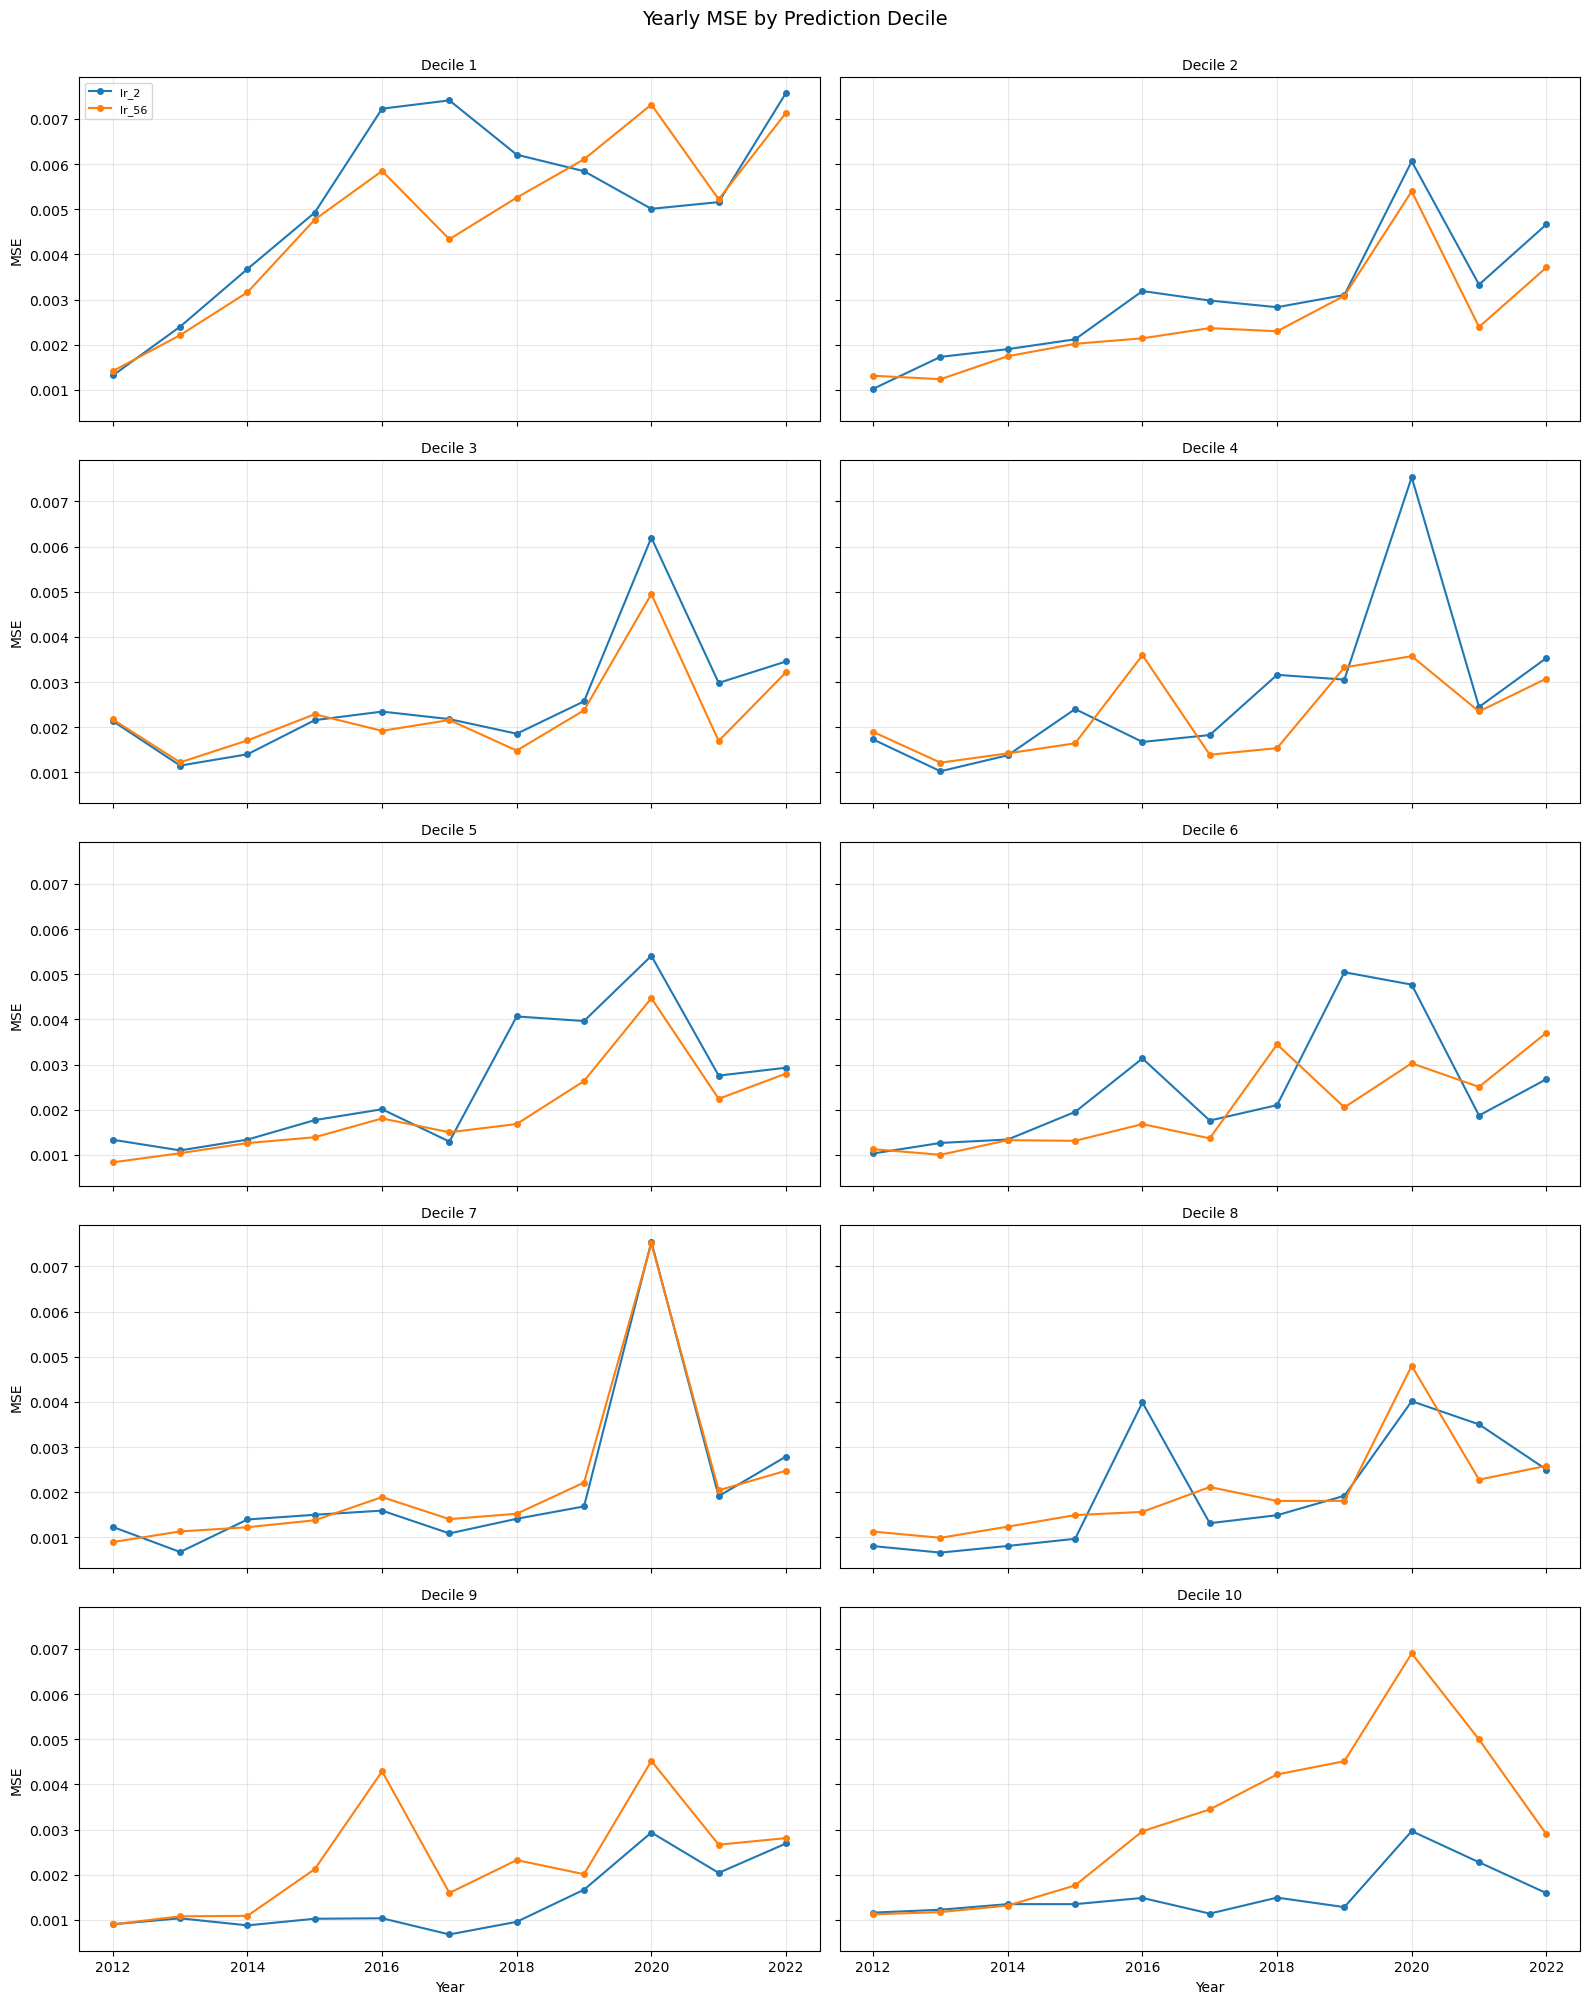

In [160]:
# Yearly MSE by prediction decile (5x2 subplots, one per decile)
fig, axes = plt.subplots(5, 2, figsize=(16, 20), sharex=True, sharey=True)
fig.suptitle('Yearly MSE by Prediction Decile', fontsize=14, y=1.0)
for d in range(1, 11):
    ax = axes[(d - 1) // 2, (d - 1) % 2]
    for col in model_cols:
        subset = df[df[f'decile_{col}'] == d]
        yearly_mse = subset.groupby('year').apply(
            lambda g: ((g[TARGET] - g[col]) ** 2).mean()
        )
        ax.plot(yearly_mse.index, yearly_mse.values, marker='o', markersize=4, label=col)
    ax.set_title(f'Decile {d}', fontsize=10)
    ax.grid(True, alpha=0.3)
    if d == 1:
        ax.legend(fontsize=8)
    if (d - 1) % 2 == 0:
        ax.set_ylabel('MSE')
    if d >= 9:
        ax.set_xlabel('Year')
plt.tight_layout()
plt.show()

C:\Users\skazempour\AppData\Local\Temp\ipykernel_9448\1158531244.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  yearly_r2 = subset.groupby('year').apply(
C:\Users\skazempour\AppData\Local\Temp\ipykernel_9448\1158531244.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  yearly_r2 = subset.groupby('year').apply(
C:\Users\skazempour\AppData\Local\Temp\ipykernel_9448\1158531244.py:8: DeprecationWarning: D

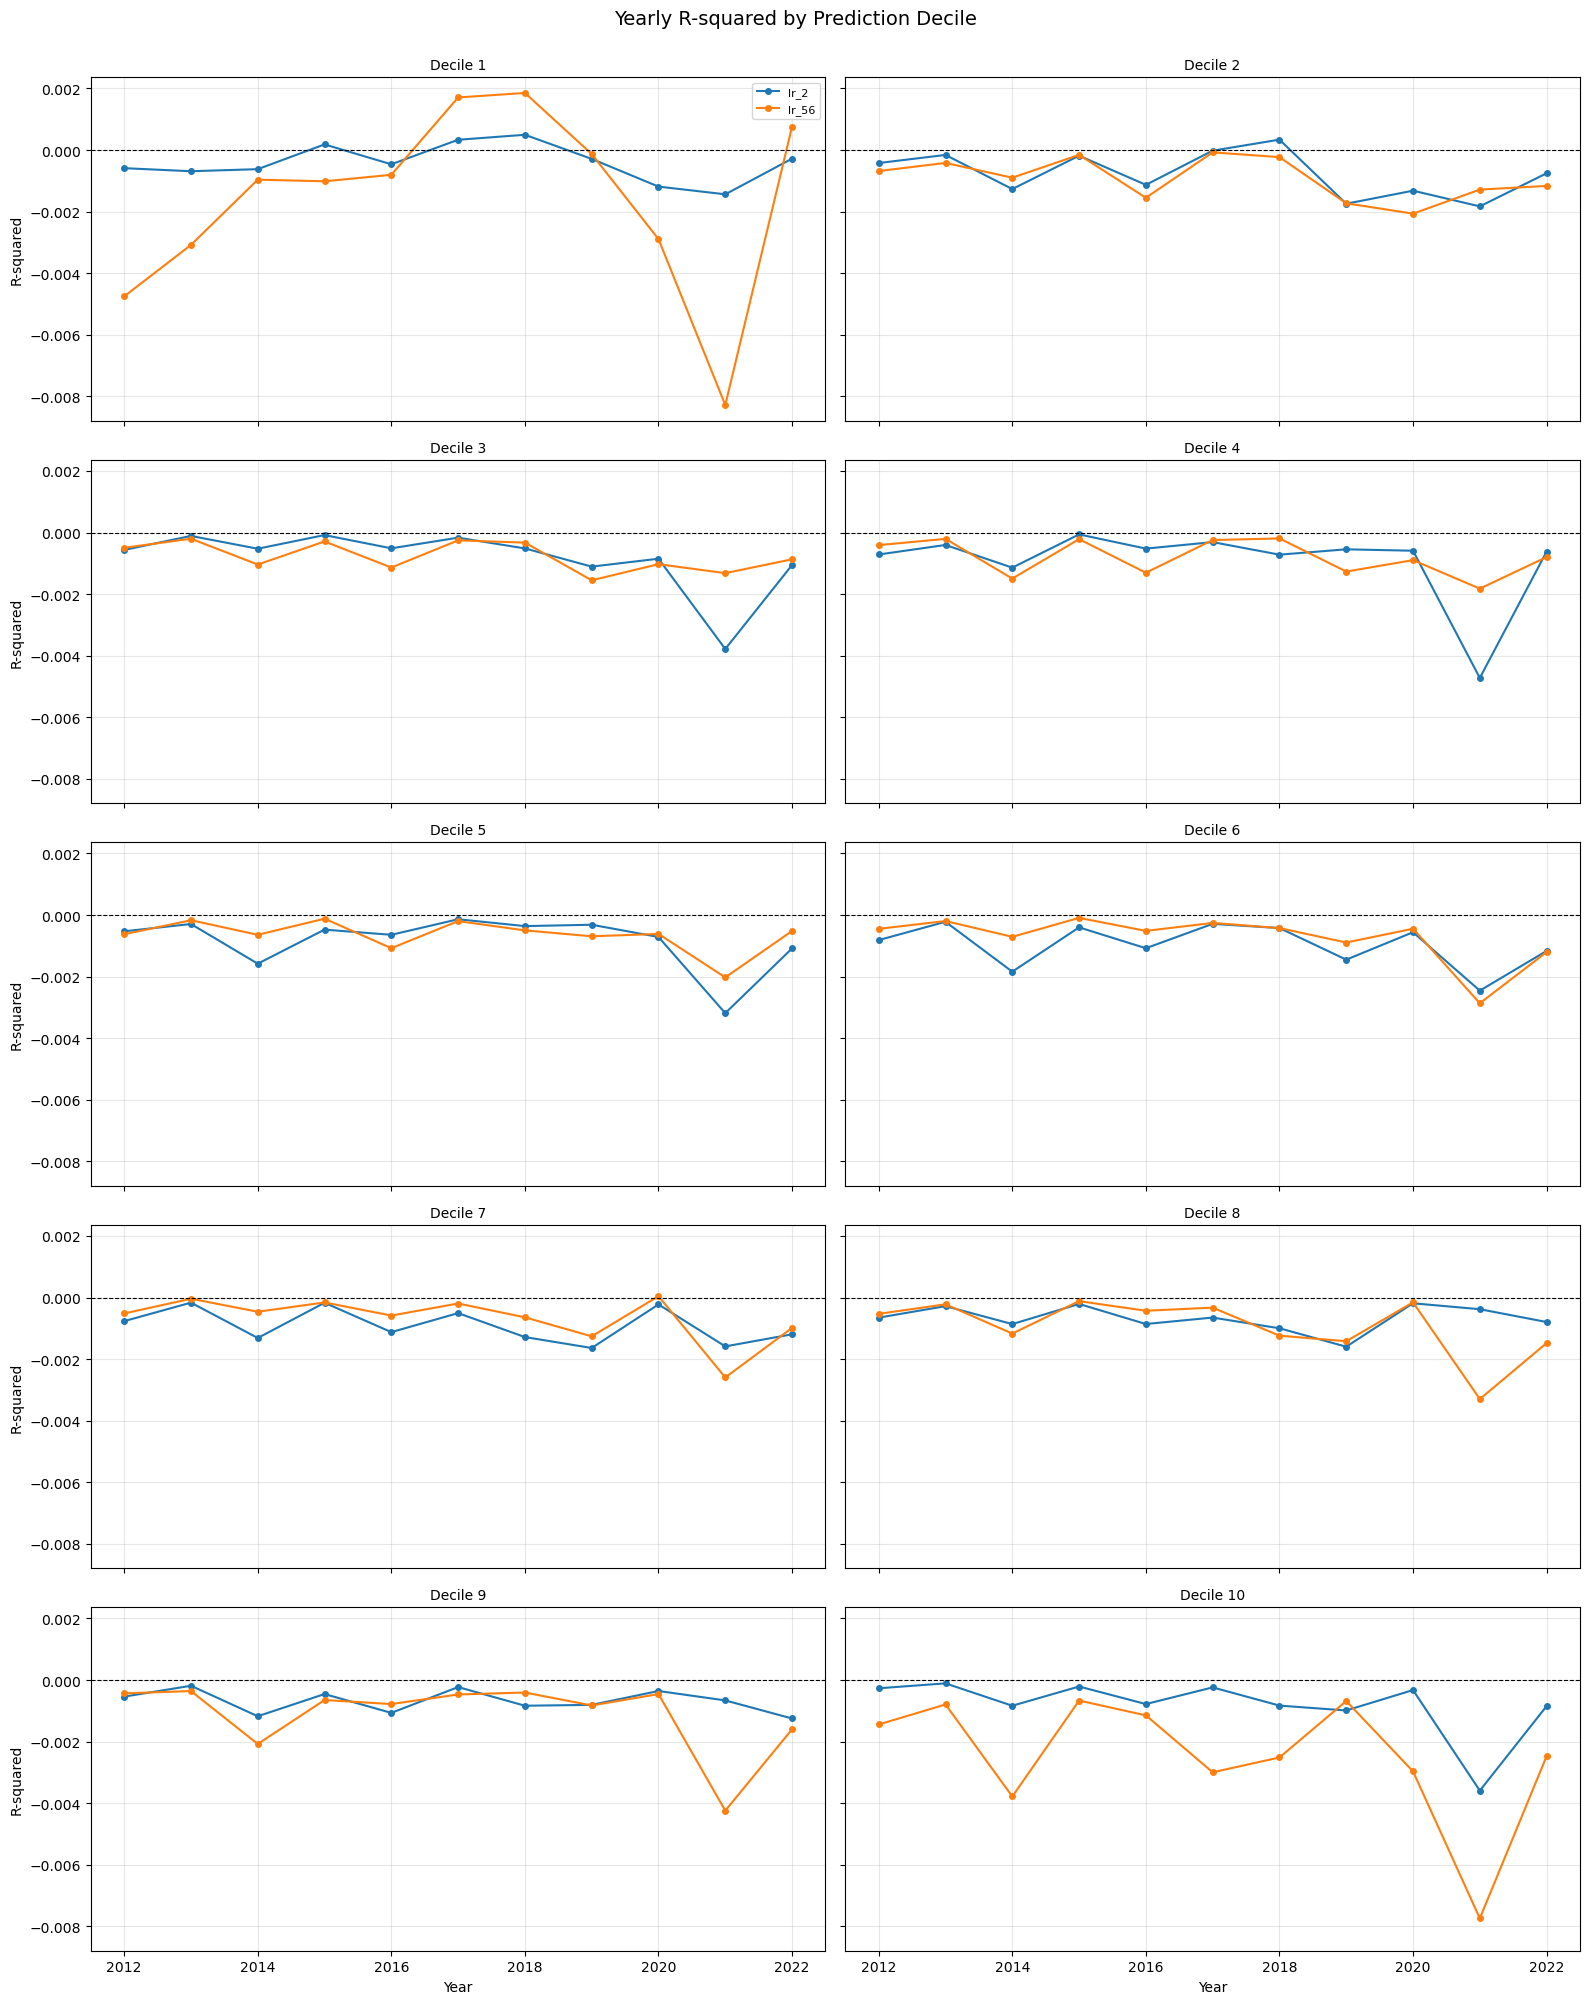

In [140]:
# Yearly R-squared by prediction decile (5x2 subplots, one per decile)
fig, axes = plt.subplots(5, 2, figsize=(16, 20), sharex=True, sharey=True)
fig.suptitle('Yearly R-squared by Prediction Decile', fontsize=14, y=1.0)
for d in range(1, 11):
    ax = axes[(d - 1) // 2, (d - 1) % 2]
    for col in model_cols:
        subset = df[df[f'decile_{col}'] == d]
        yearly_r2 = subset.groupby('year').apply(
            lambda g: 1 - ((g[TARGET] - g[col]) ** 2).sum() / ((g[TARGET] - g[TARGET].mean()) ** 2).sum()
        )
        ax.plot(yearly_r2.index, yearly_r2.values, marker='o', markersize=4, label=col)
    ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
    ax.set_title(f'Decile {d}', fontsize=10)
    ax.grid(True, alpha=0.3)
    if d == 1:
        ax.legend(fontsize=8)
    if (d - 1) % 2 == 0:
        ax.set_ylabel('R-squared')
    if d >= 9:
        ax.set_xlabel('Year')
plt.tight_layout()
plt.show()

C:\Users\skazempour\AppData\Local\Temp\ipykernel_9448\3942134452.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly_mse = subset.groupby('year_month').apply(
C:\Users\skazempour\AppData\Local\Temp\ipykernel_9448\3942134452.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly_mse = subset.groupby('year_month').apply(
C:\Users\skazempour\AppData\Local\Temp\ipykernel_9448\3942134452.py:8: Depre

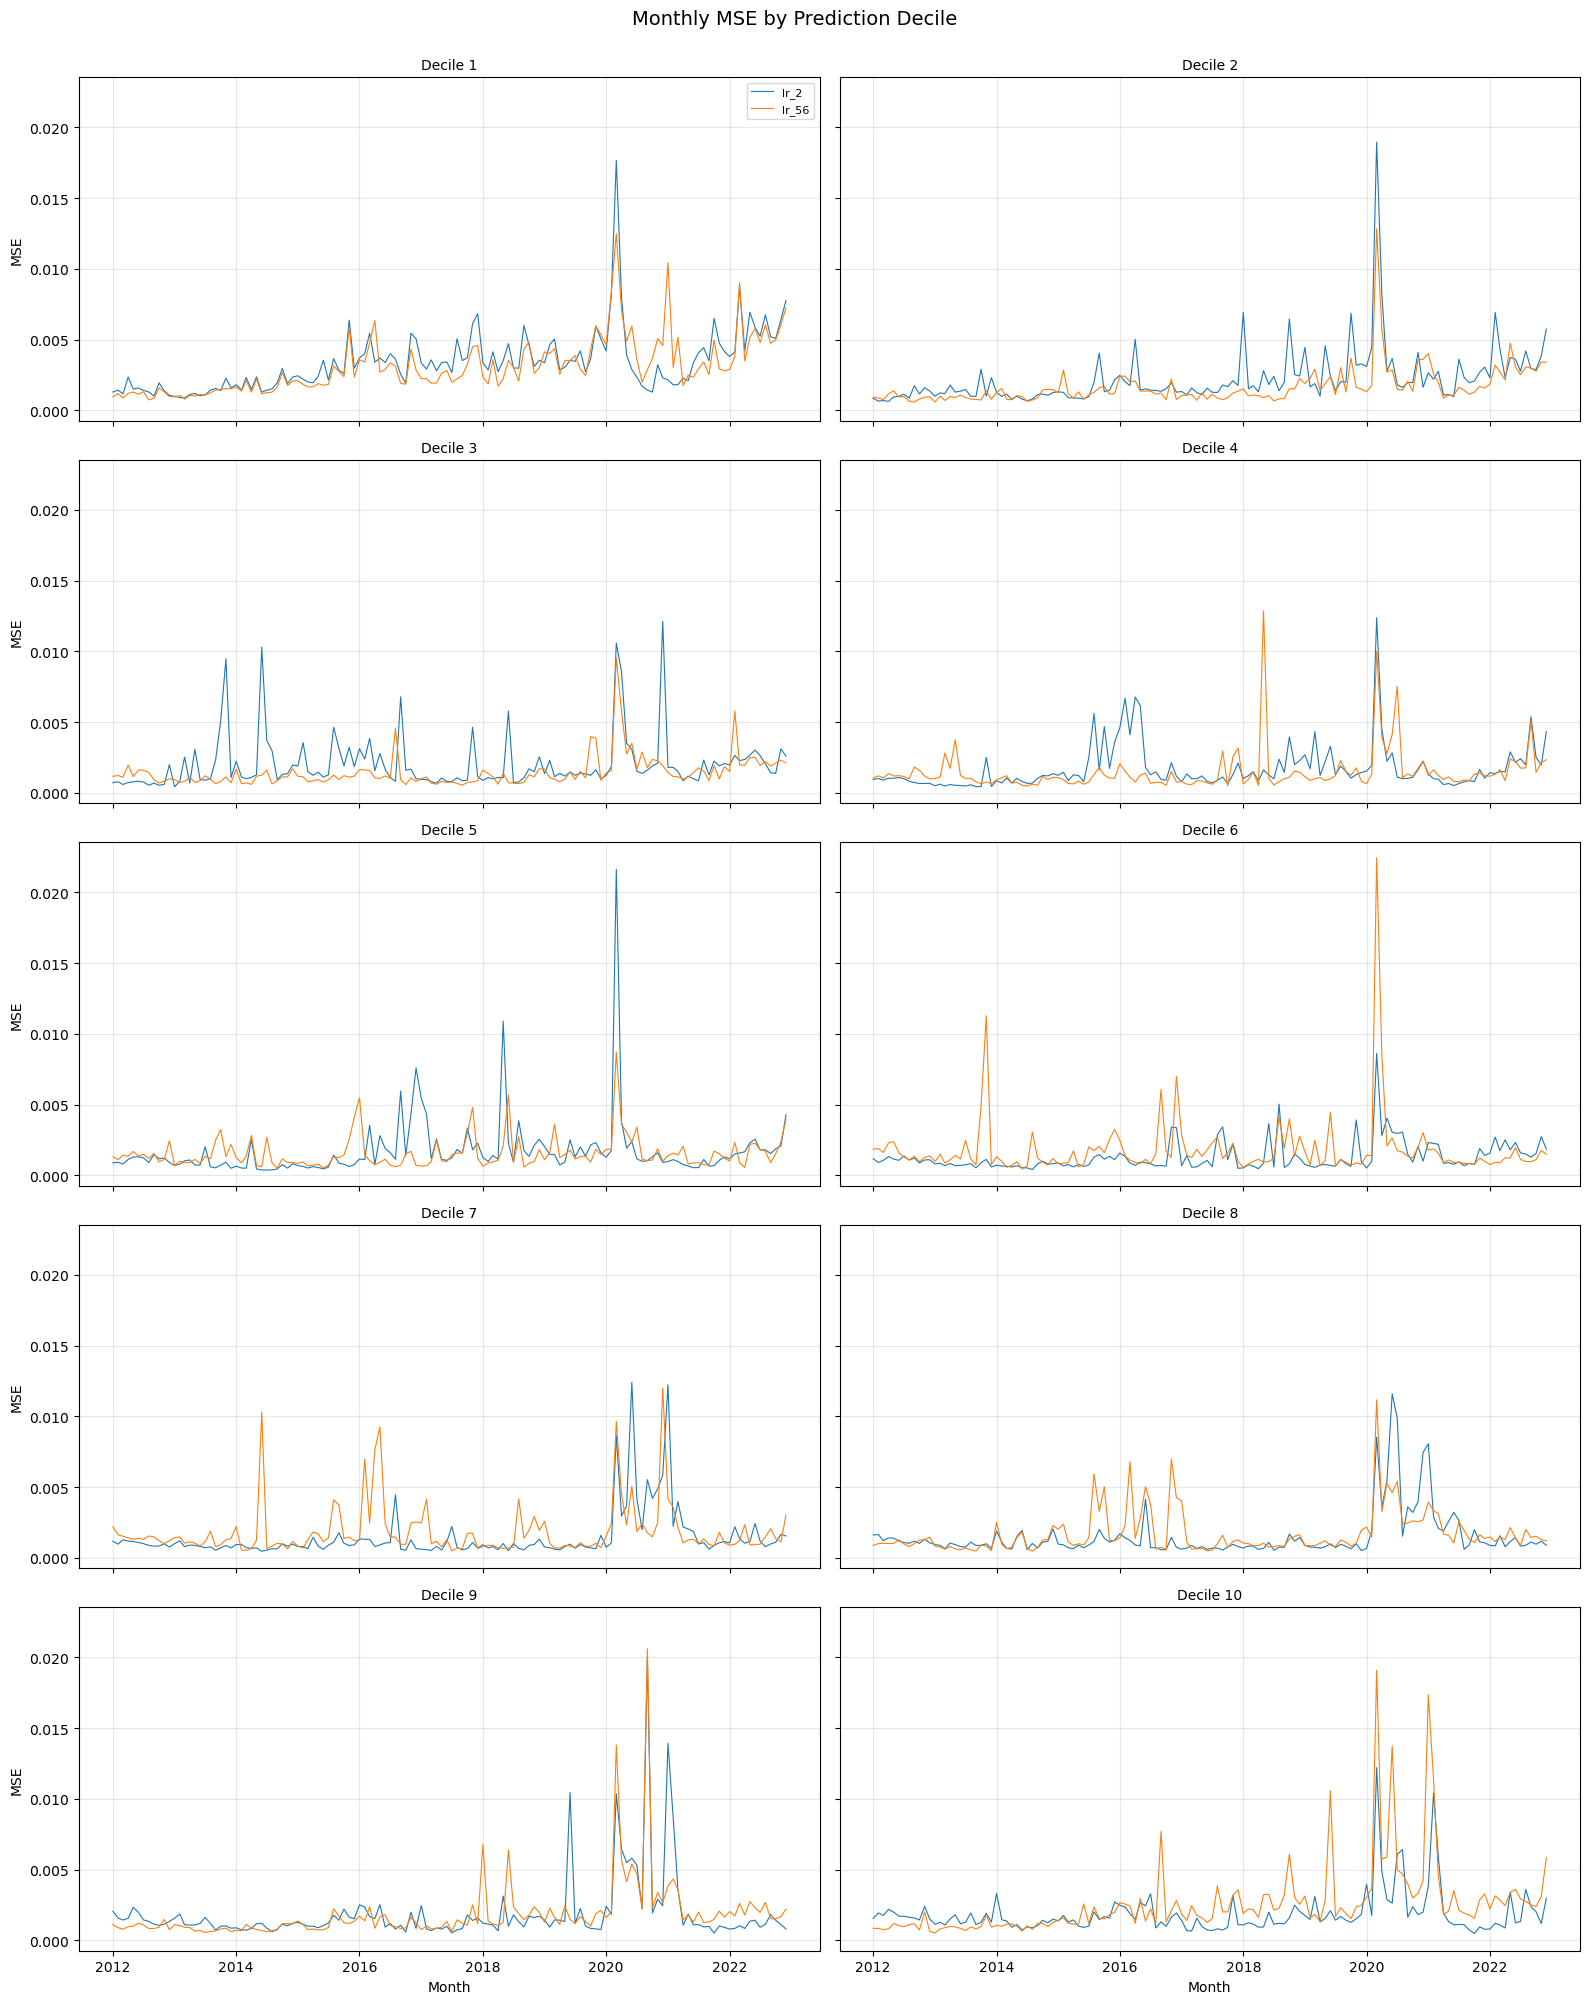

In [141]:
# Monthly MSE by prediction decile (5x2 subplots, one per decile)
fig, axes = plt.subplots(5, 2, figsize=(16, 20), sharex=True, sharey=True)
fig.suptitle('Monthly MSE by Prediction Decile', fontsize=14, y=1.0)
for d in range(1, 11):
    ax = axes[(d - 1) // 2, (d - 1) % 2]
    for col in model_cols:
        subset = df[df[f'decile_{col}'] == d]
        monthly_mse = subset.groupby('year_month').apply(
            lambda g: ((g[TARGET] - g[col]) ** 2).mean()
        )
        ax.plot(monthly_mse.index.to_timestamp(), monthly_mse.values, label=col, linewidth=0.8)
    ax.set_title(f'Decile {d}', fontsize=10)
    ax.grid(True, alpha=0.3)
    if d == 1:
        ax.legend(fontsize=8)
    if (d - 1) % 2 == 0:
        ax.set_ylabel('MSE')
    if d >= 9:
        ax.set_xlabel('Month')
plt.tight_layout()
plt.show()

C:\Users\skazempour\AppData\Local\Temp\ipykernel_9448\3080379162.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly_r2 = subset.groupby('year_month').apply(
C:\Users\skazempour\AppData\Local\Temp\ipykernel_9448\3080379162.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly_r2 = subset.groupby('year_month').apply(
C:\Users\skazempour\AppData\Local\Temp\ipykernel_9448\3080379162.py:8: Depreca

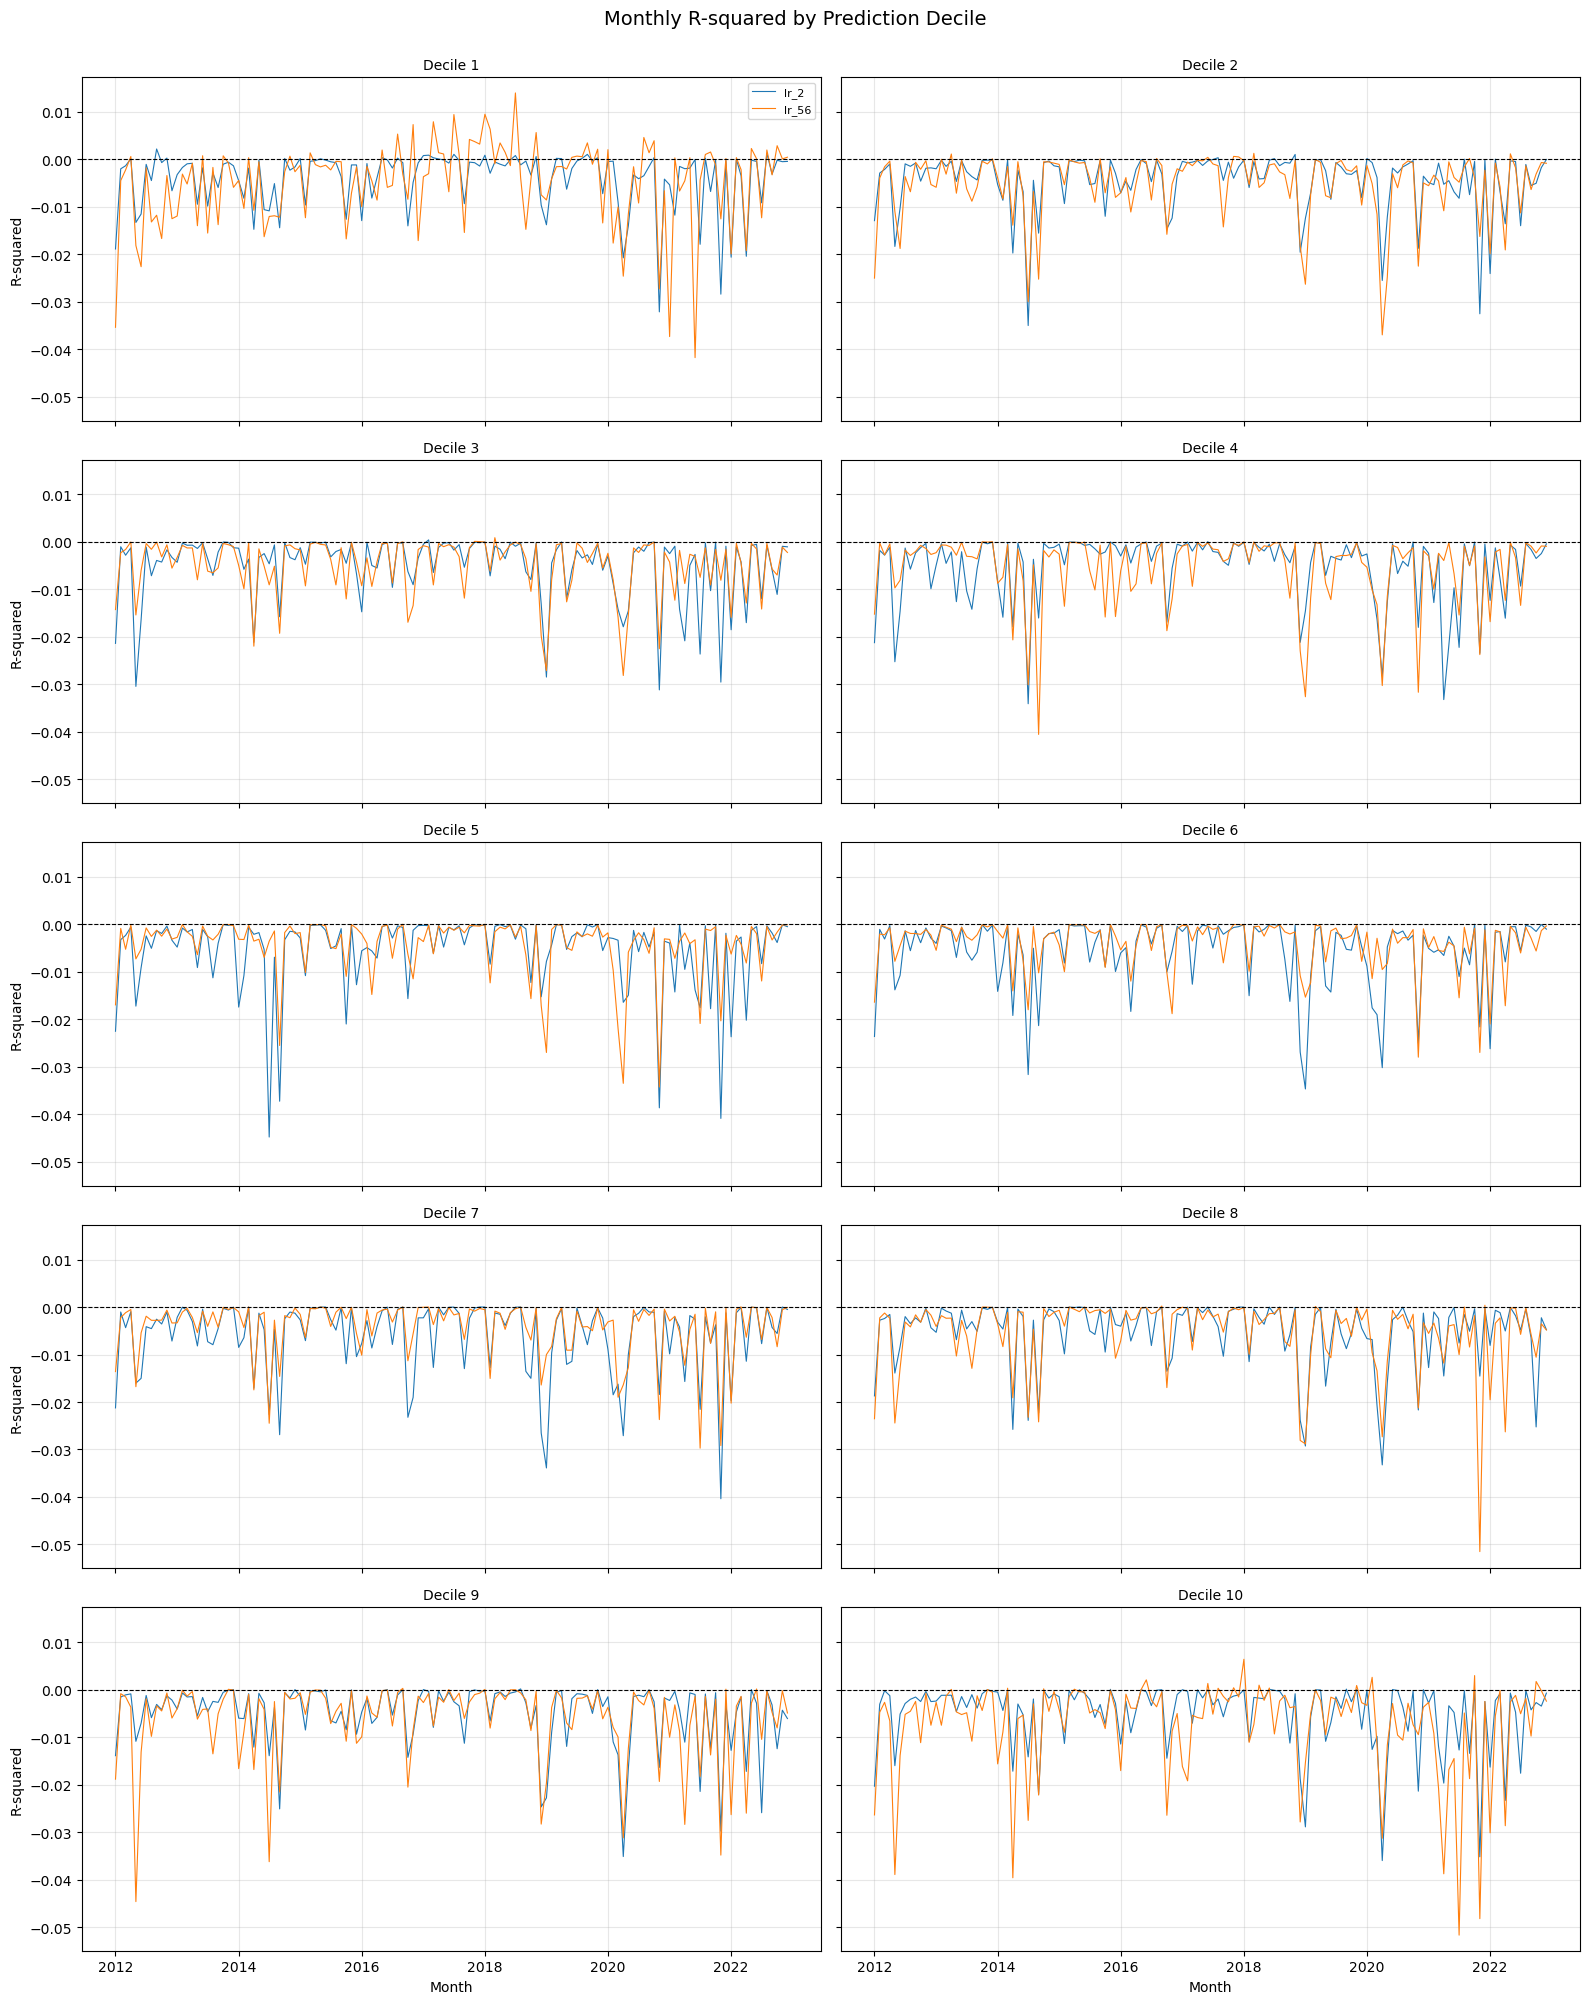

In [142]:
# Monthly R-squared by prediction decile (5x2 subplots, one per decile)
fig, axes = plt.subplots(5, 2, figsize=(16, 20), sharex=True, sharey=True)
fig.suptitle('Monthly R-squared by Prediction Decile', fontsize=14, y=1.0)
for d in range(1, 11):
    ax = axes[(d - 1) // 2, (d - 1) % 2]
    for col in model_cols:
        subset = df[df[f'decile_{col}'] == d]
        monthly_r2 = subset.groupby('year_month').apply(
            lambda g: 1 - ((g[TARGET] - g[col]) ** 2).sum() / ((g[TARGET] - g[TARGET].mean()) ** 2).sum()
        )
        ax.plot(monthly_r2.index.to_timestamp(), monthly_r2.values, label=col, linewidth=0.8)
    ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
    ax.set_title(f'Decile {d}', fontsize=10)
    ax.grid(True, alpha=0.3)
    if d == 1:
        ax.legend(fontsize=8)
    if (d - 1) % 2 == 0:
        ax.set_ylabel('R-squared')
    if d >= 9:
        ax.set_xlabel('Month')
plt.tight_layout()
plt.show()

# Plots

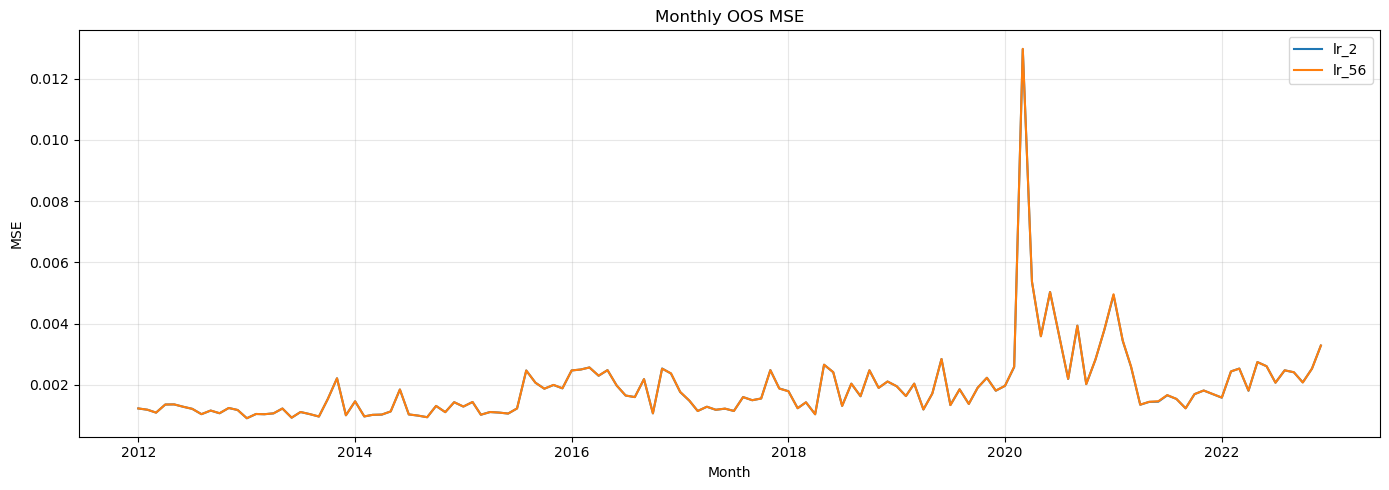

In [143]:
# Monthly MSE
fig, ax = plt.subplots(figsize=(14, 5))
x = monthly.index.to_timestamp()
for col in model_cols:
    ax.plot(x, monthly[f'MSE_{col}'], label=col)
ax.set_xlabel('Month')
ax.set_ylabel('MSE')
ax.set_title('Monthly OOS MSE')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

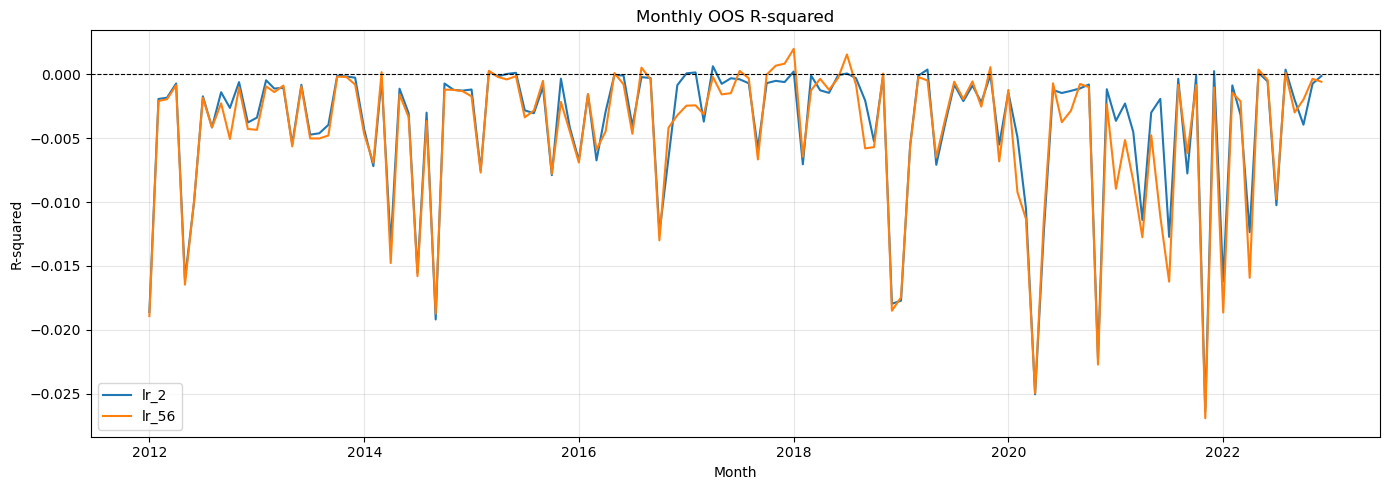

In [144]:
# Monthly R-squared
fig, ax = plt.subplots(figsize=(14, 5))
x = monthly.index.to_timestamp()
for col in model_cols:
    ax.plot(x, monthly[f'R2_{col}'], label=col)
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
ax.set_xlabel('Month')
ax.set_ylabel('R-squared')
ax.set_title('Monthly OOS R-squared')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

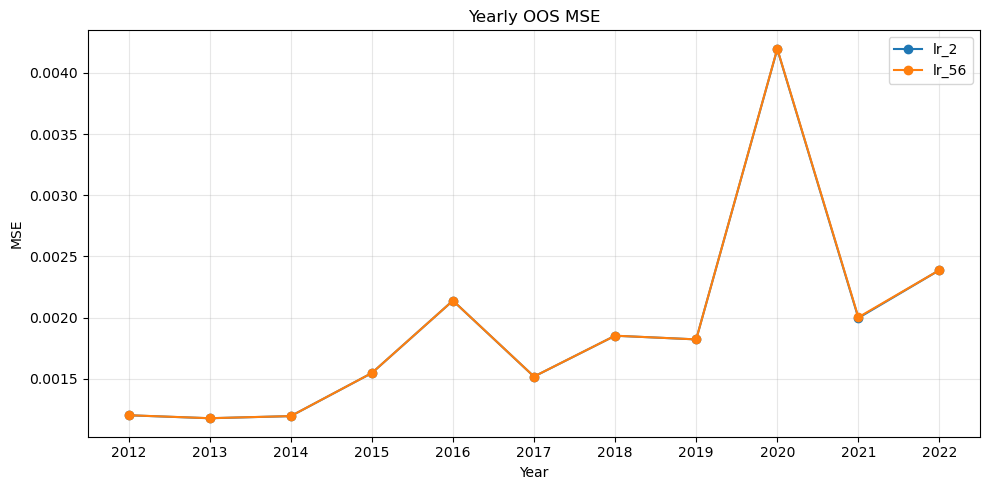

In [145]:
# Yearly MSE
fig, ax = plt.subplots(figsize=(10, 5))
x = yearly.index.astype(int)
for col in model_cols:
    ax.plot(x, yearly[f'MSE_{col}'], marker='o', label=col)
ax.set_xlabel('Year')
ax.set_ylabel('MSE')
ax.set_title('Yearly OOS MSE')
ax.set_xticks(x)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

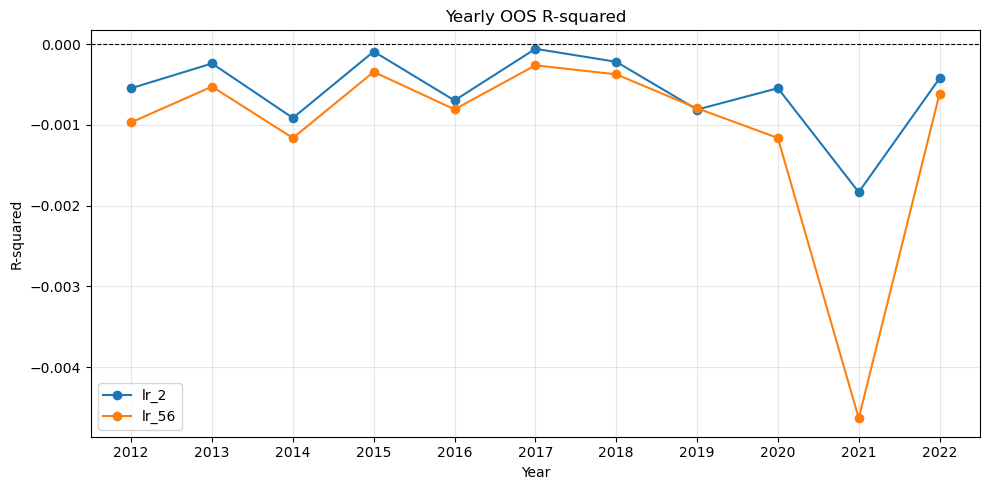

In [146]:
# Yearly R-squared
fig, ax = plt.subplots(figsize=(10, 5))
x = yearly.index.astype(int)
for col in model_cols:
    ax.plot(x, yearly[f'R2_{col}'], marker='o', label=col)
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
ax.set_xlabel('Year')
ax.set_ylabel('R-squared')
ax.set_title('Yearly OOS R-squared')
ax.set_xticks(x)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()